In [371]:
import requests
import io
from datetime import datetime, UTC
from zoneinfo import ZoneInfo
from pprint import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from matplotlib.patches import Polygon
import geopandas as gpd
from shapely.geometry import Polygon, Point, shape, box
from shapely.plotting import plot_polygon
from shapely import minimum_bounding_radius
import textwrap
from collections import Counter

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import warnings
warnings.filterwarnings('ignore')

In [3]:
gdf = gpd.read_file('./cb_2018_us_county_20m/cb_2018_us_county_20m.shp')
gdf["STATEFP"] = gdf["STATEFP"].astype(str).str.zfill(2)

calnev_counties = gdf[(gdf["STATEFP"] == "06") | (gdf["STATEFP"] == "32")]

In [4]:
"""
Algorithm condenses long lists of counties if they exceed a 
certain amount of characters to make space for the box (NHK style).

These regions are chosen arbitrarily by me but I'm going 
by what's generally used by locals/on the internet,
basing mainly off definitions in Wikipedia

Regions defined for Nevada would probably rarely be used, 
except for Western Nevada because most NV earthquakes occur there.
The rest of NV regions have large counties, and don't usually
have very large earthquakes that would require condensing the list.

There is a Humboldt County in both states. These would most likely
never get an EEW at the same time. The NV one is not defined in
a region for the reasons above.

Some blank strings are added so the threshold for condensing
a region doesn't get triggered at 1 or 2 counties in regions with few.
Threshold is (# of counties) - 3
"""

regions = {
    # ---- Northern California ----
    # Del Norte, Humboldt, Lake, Mendocino
    # "North Coast": ['015', '023', '033', '045'],
    "North Coast": ['Del Norte', 'Humboldt', 'Lake', 'Mendocino','',''],

    # Butte, Lassen, Modoc, Plumas, Shasta, Siskiyou, Tehama, Trinity
    # "The Cascades": ['007','035','049','063','089','103','105'],
    "The Cascades": ['Butte', 'Lassen', 'Modoc', 'Plumas', 'Shasta', 'Siskiyou', 'Tehama', 'Trinity'],

    # Plumas, Sierra, Nevada, Placer, Yuba, El Dorado, Amador, Alpine, Calaveras, Tuolumne, Mariposa, Mono, Madera, Tulare, Inyo
    # "Sierra Nevada": ['063', '091','057','061','115','017','005','003','009','109','043','051','039','107','027'],
    "Sierra Nevada": [
        'Plumas', 'Sierra', 'Nevada', 'Placer', 'Yuba', 'El Dorado', 'Amador', 
        'Alpine', 'Calaveras', 'Tuolumne', 'Mariposa', 'Mono', 'Madera', 'Tulare', 'Inyo'
        ],

    # Butte, Colusa, Glenn, Placer, Sacramento, Shasta, Sutter, Tehama, Yolo, Yuba
    # "Sacramento Valley": ['007','011','021','061','067','089','101','103','113','115'],
    "Sacramento Valley": [
        'Butte', 'Colusa', 'Glenn', 'Placer', 'Sacramento', 
        'Shasta', 'Sutter', 'Tehama', 'Yolo', 'Yuba'
        ],

    # San Joaquin, Kings, Stanislaus, Merced, Fresno, Madera, Tulare, Kern
    # "San Joaquin Valley": ['077','031','099','047','019','039','107','029'],
    "San Joaquin Valley": ['San Joaquin', 'Kings', 'Stanislaus', 'Merced', 'Fresno', 'Madera', 'Tulare', 'Kern'],

    # Alameda, Contra Costa, Marin, Napa, San Mateo, Santa Clara, Solano, Sonoma, San Francisco, Santa Cruz
    # "Bay Area": ['001','013','041','055','081','085','095','097','075','087'],
    "Bay Area": [
        'Alameda', 'Contra Costa', 'Marin', 'Napa', 'San Mateo', 
        'Santa Clara', 'Solano', 'Sonoma', 'San Francisco', 'Santa Cruz'
        ],

    # ---- Southern California ----
    # Santa Barbara, San Luis Obispo, Monterey, San Benito, Santa Cruz
    # "Central Coast": ['083','079','053','069','087'],
    "Central Coast": ['Santa Barbara', 'San Luis Obispo', 'Monterey', 'San Benito', 'Santa Cruz'],

    # Ventura, Los Angeles, Orange, Riverside, San Bernardino
    # "Greater LA Metro": ['111','037','059','065','071'],
    "Greater LA Metro": ['Ventura', 'Los Angeles', 'Orange', 'Riverside', 'San Bernardino', '', ''],

    #Inyo, San Bernardino, Riverside, Imperial
    # "Southeastern CA": ['027','071','065','025'],
    "Southeastern CA": ['Inyo', 'San Bernardino','Riverside', 'Imperial', '', ''],


    # ---- Nevada ----
    # Washoe, Carson City, Douglas, Storey, Lyon
    # "Western NV": ['031','510','005','029','019'],
    "Western NV": ['Washoe', 'Carson City', 'Douglas', 'Storey', 'Lyon'],
}

In [536]:
def mmi_style(mmi,to_shindo=False):
    """Manages shaking-related language and styling depending on the measured intensity of the earthquake."""
    if mmi == 0: mmi = 1
    if mmi > 10: mmi = 10
                                                                    # orange and darkorange look too similar
    box_colors = ['white','lightblue','cyan','blue','green','yellow','orange','brown','red','darkred']
    txt_colors = ['k',    'k',    'k',       'w',   'w',    'k',      'k',     'w',        'w',  'y']
    weights =    [400,     400,    400,       400,   400,    400,      400,     600,       700,   800]
    fontsizes =  [10,       10,     10,        10,    10,     10,       10,       7.5,        12,    12]
    MMI_ticks =  ['I',    'II',   'III',     'IV',  'V',    'VI',     'VII',   'VIII',     'IX',  'X']
    shindo =     ['0',     '1',    '2',       '3',   '4',   '5-',     '5+',    '6-',       '6+',  '7']
    descriptions = [
        'Not felt',
        'Weak',
        'Very light',
        'Light',
        'Moderate',
        'Strong',
        'Very strong',
        'Severe',
        'Violent',
        'Extreme'
    ]

    box_color = box_colors[mmi-1]
    txt_color = txt_colors[mmi-1]
    fnt_weight = weights[mmi-1]
    fnt_size = fontsizes[mmi-1]
    numeral = MMI_ticks[mmi-1]
    if to_shindo: numeral = shindo[mmi-1]
    description = descriptions[mmi-1]    

    return box_color, txt_color, fnt_weight, fnt_size, numeral, description

def mag_style(mag):
    """Manages strength-related language depending on the magnitude of the earthquake."""
    if mag <= 4.0:
        desc = "A minor earthquake"
    if 4.0 <= mag < 5.2:
        desc = "A moderate earthquake"
    if 5.3 <= mag < 5.9:
        desc = "A moderately strong earthquake"
    if 6.0 <= mag < 6.6:
        desc = "A very strong earthquake"
    if mag >= 6.7:
        desc = "A major earthquake"

    return desc

In [6]:
lims = [-127.376, -112.412, 31.166, 42.656]

In [599]:
url = 'https://earthquake.usgs.gov/fdsnws/event/1/query'
query = {
    "format": "geojson",
    "starttime": '2026-01-01',
    "minmagnitude": '3.2',
    "minlongitude": lims[0],
    "maxlongitude": lims[1],
    "minlatitude": lims[2],
    "maxlatitude": lims[3],
    
}
r = requests.get(url, params=query)

if r.status_code == 200:
    data = r.json()
else:
    data = None
    print("error")

# pprint(data['features'])
[(i,feat['properties']['title']) for i, feat in enumerate(data['features'])]

[(0, 'M 3.6 - 0 km W of Angwin, CA'),
 (1, 'M 3.2 - 13 km NNE of Avalon, CA'),
 (2, 'M 3.9 - 15 km NNE of Alder Springs, CA'),
 (3, 'M 3.4 - 12 km N of Ocotillo Wells, CA'),
 (4, 'M 3.3 - 17 km WSW of Johannesburg, CA'),
 (5, 'M 5.6 - 11 km N of Redwood Valley, CA'),
 (6, 'M 3.4 - 5 km SW of Ridgemark, CA'),
 (7, 'M 3.6 - 21 km N of Searles Valley, CA'),
 (8, 'M 4.1 - 179 km WSW of Port Orford, Oregon'),
 (9, 'M 3.6 - 18 km WSW of Johannesburg, CA'),
 (10, 'M 3.6 - 10 km SW of Niland, CA'),
 (11, 'M 3.2 - 2 km ESE of Prattville, CA'),
 (12, 'M 3.3 - 8 km NW of The Geysers, CA'),
 (13, 'M 4.0 - 20 km ESE of Silver Springs, Nevada'),
 (14, 'M 3.6 - 3 km SW of Alamo, CA'),
 (15, 'M 3.4 - 15 km NW of Fillmore, CA'),
 (16, 'M 3.8 - 11 km NW of Summerlin South, Nevada'),
 (17, 'M 4.5 - 61 km W of Petrolia, CA'),
 (18, 'M 4.0 - 61 km W of Petrolia, CA'),
 (19, 'M 4.5 - 64 km W of Petrolia, CA'),
 (20, 'M 5.1 - 62 km W of Petrolia, CA'),
 (21, 'M 5.7 - 143 km WSW of Pistol River, Oregon'),
 (2

In [606]:
event = data['features'][51]
ev_name = event['properties']['title']
ev_time = event['properties']['time']
ev_utc = datetime.fromtimestamp(ev_time / 1000, UTC)
ev_local = ev_utc.astimezone(ZoneInfo("America/Los_Angeles"))
time_str = ev_local.strftime("%b %d, %Y %H:%M")
print(ev_name)
print(time_str)
event_detail_url = event['properties']['detail']
r2 = requests.get(event_detail_url)
ss_detail = r2.json()

has_eew = True
try:
    eew_url = ss_detail['properties']['products']['shake-alert'][-1]['contents']['summary.json']['url']
    r3 = requests.get(eew_url)
    eew_data = r3.json()
    print('EEW report loaded')
except:
    has_eew = False
    print("Event has no ShakeAlert product.")

M 3.2 - 7 km SE of Loma Linda, CA
May 08, 2026 18:40
Event has no ShakeAlert product.


In [607]:
try:
    alert = eew_data['alerts'][-1]['features']
except:
    alert = eew_data['final_alert']['features']
# pprint(alert)

for feature in alert:
    if feature.get('id') == 'Epicenter' or feature.get('id') == 'finalEpicenter':
        epi_feat = feature
        continue
    
    featMMI = feature['properties'].get('name')
    if featMMI == 'MMI 4' or featMMI == "MMI 3.5":
    # if feature.get('id') == 'poly_2':
        MMI = feature['properties']['name']
        print(MMI)
        polygon_feat = feature

alert_poly = shape(polygon_feat)
epix, epiy = epi_feat['geometry']['coordinates']

MMI 3.5


In [608]:
# calnev_counties['warned'] = gdf.intersects(alert_poly)
calnev_counties["intersect_area"] = calnev_counties.geometry.intersection(alert_poly).area
calnev_counties["cover_ratio"] = calnev_counties["intersect_area"] / calnev_counties.geometry.area
calnev_counties["warned"] = calnev_counties["cover_ratio"] > 0.05
colors = calnev_counties['warned'].map({True: 'yellow', False: 'white'})

warned_names = calnev_counties[calnev_counties['warned']==True]['NAME'].tolist()
warned_fips = calnev_counties[calnev_counties['warned']==True]['COUNTYFP'].tolist()

In [609]:
regions_used = False

# about 400 characters should be able to fit in the text box
if len("".join(warned_names)) >= 50:
    warned_areas = list(warned_names)  # Use list, not numpy array
    condensed_counties = set()

    # Tally which regions are warned
    regions_tally = []
    for county in warned_names:
        for r in regions:
            if county in regions[r]:
                regions_tally.append(r)

    warns_per_region = Counter(regions_tally)

    # First pass: identify and add condensed regions
    for r in reversed(regions):
        if warns_per_region[r] >= len(regions[r]) - 3 or warns_per_region[r] > 7:
            print(f"Region {r} had {warns_per_region[r]} (max {len(regions[r])}) warnings and will be condensed")
            warned_areas.insert(0, r)  # Add region to front
            regions_used = True
            # Mark all warned counties in this region as condensed
            for county in regions[r]:
                if county in warned_names:
                    condensed_counties.add(county)

    # Second pass: remove condensed counties, add "Co." to remaining
    final_warned_areas = []
    for area in warned_areas:
        if area in regions.keys():  # It's a region name
            final_warned_areas.append(area)
        elif area not in condensed_counties:  # It's a county not in any condensed region
            final_warned_areas.append(f"{area} Co.")

    print(f'final list {final_warned_areas}')
else: 
    final_warned_areas = warned_names

Region North Coast had 3 (max 6) warnings and will be condensed
final list ['North Coast', 'Napa Co.', 'Colusa Co.', 'Trinity Co.', 'Yolo Co.', 'Sonoma Co.', 'Butte Co.', 'Sutter Co.', 'Tehama Co.', 'Glenn Co.']


In [610]:
if has_eew:
    fig, axi = plt.subplots(1,1,figsize=(15,15), subplot_kw={'projection': ccrs.PlateCarree()})

    calnev_counties.plot(ax=axi,color=colors,edgecolor='black',linewidth=0.5)

    # poly_diameter = minimum_bounding_radius(alert_poly) * 2
    # print(poly_diameter)
    # poly_diameter = max(poly_diameter,1)
    # map_lims = [epix - poly_diameter, epix + poly_diameter, epiy - poly_diameter/1.5, epiy + poly_diameter/1.5]
    pad = 1.5
    x1, y1, x2, y2 = calnev_counties[calnev_counties['warned']==True].total_bounds
    map_lims = (x1 - pad, x2 + pad, y1 - pad/1.5, y2 + pad/1.5)
    try:
        axi.set_extent(map_lims)
    except:
        axi.set_extent(lims)

    # axi.add_feature(cfeature.COASTLINE)
    # axi.add_feature(cfeature.BORDERS, linestyle=':')
    axi.add_feature(cfeature.LAND, edgecolor='black')
    axi.add_feature(cfeature.LAKES, edgecolor='black')
    axi.add_feature(cfeature.RIVERS)
    # axi.add_feature(cfeature.STATES)
    axi.add_feature(cfeature.OCEAN)


    ew_style = dict(boxstyle='square', facecolor='red', edgecolor='black')
    axi.text(0.5,0.98,'EARTHQUAKE WARNING',transform=axi.transAxes,fontsize=36,color='w',fontweight='bold',bbox=ew_style,va='top',ha='center')

    psa_text = "Drop, cover, hold on.\nShaking expected in the following counties:"
    if regions_used: psa_text = "Drop, cover, hold on.\nShaking expected in the following regions/counties:"
    psa_style = dict(boxstyle='square', facecolor='blue', edgecolor='black')
    axi.text(0.5,0.91,psa_text,transform=axi.transAxes,fontsize=16,color='yellow',bbox=psa_style,va='top',ha='center')

    warn_text = "\n".join(textwrap.wrap("        ".join(final_warned_areas), width=60))
    clist_style = dict(boxstyle='square', facecolor='blue', edgecolor='k', pad=0.6)
    axi.text(0.5,0.05,warn_text,transform=axi.transAxes,fontsize=18,color='w',fontweight='bold',bbox=clist_style,va='bottom',ha='center')

    axi.scatter(epix,epiy,marker='X',c='r',ec='white',linewidths=2,s=750)
    # plot_polygon(alert_poly)

    # axi.set_title(f"Example: {event['properties']['title']}, threshold {MMI}")
    plt.show()
else:
    print("No EEW was issued for this event.")

No EEW was issued for this event.


No losspager. Using dyfi txt


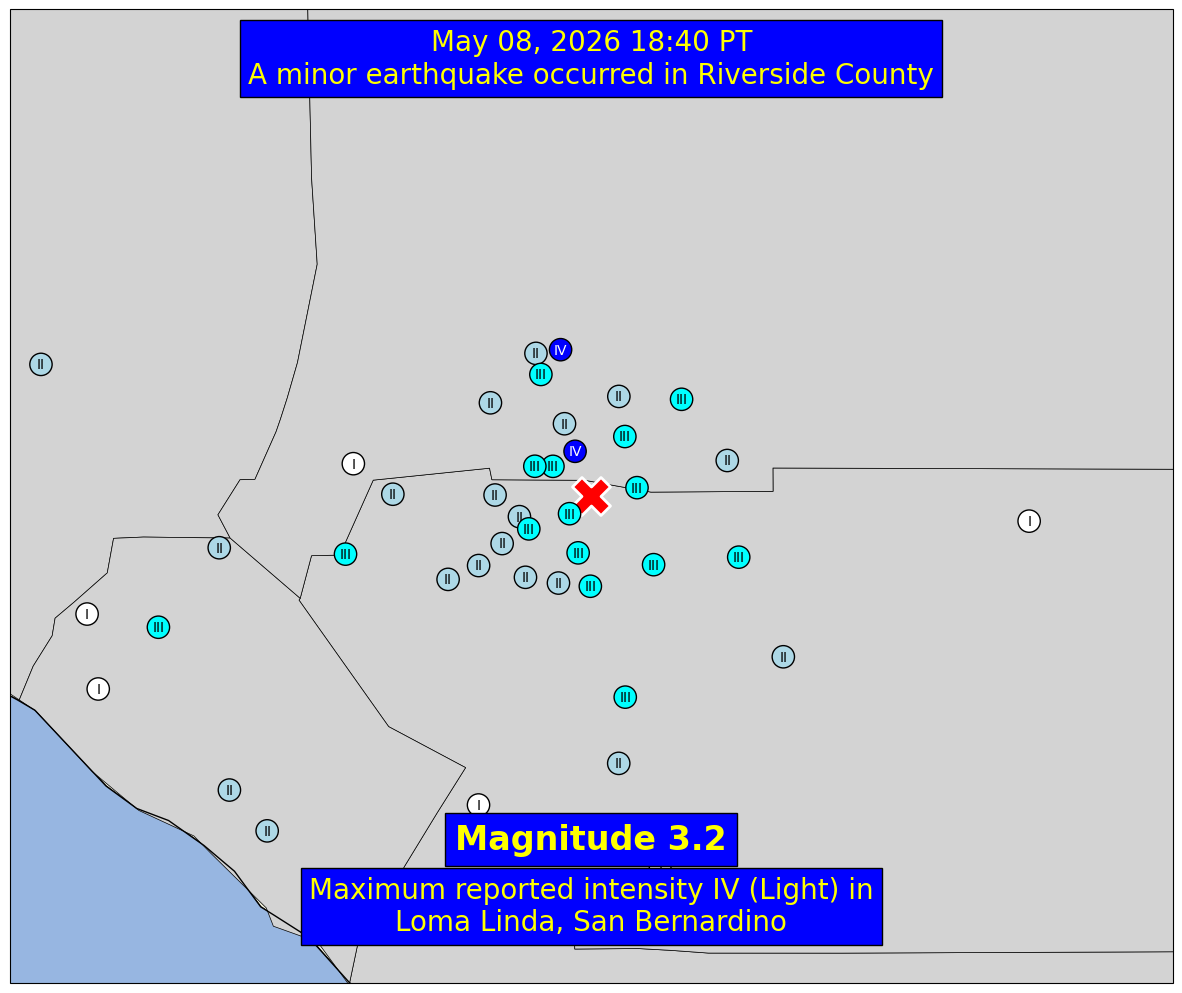

In [611]:
dyfi_used = False
try:
    city_mmi_url = ss_detail['properties']['products']['losspager'][0]['contents']['json/cities.json']['url']
    r4 = requests.get(city_mmi_url)
    city_mmis = r4.json()

    source_data = ss_detail['properties']['products']['losspager'][0]['properties']
    epix, epiy = float(source_data['longitude']), float(source_data['latitude'])
    mag = float(source_data['magnitude'])
    # alternative map centering on epicenter, bad for offshore earthquakes
    # x1, x2, y1, y2 = (epix - box_hl, epix + box_hl, epiy - box_hl/1.5, epiy + box_hl/1.5)

    names = []
    coord_pairs = []
    mmis = []

    for city in city_mmis['all_cities']:
        # if city['on_map']:
        names.append(city['name'])
        coord_pairs.append((city['lon'], city['lat']))
        mmis.append(city['mmi'])
    data_plottable = True
    # end of losspager data. Below here use dyfi if not available.
    # needed vars: names, coord pairs, mmis, mag, (epix epiy)

except KeyError:
    print("No losspager. Using dyfi txt")
    dyfi_data = ss_detail['properties']['products']['dyfi'][0]
    r4 = requests.get(dyfi_data['contents']['cdi_zip.txt']['url'])
    txt_zip_mmis = r4.text
    zip_mmis = pd.read_csv(io.StringIO(txt_zip_mmis))

    names = []
    coord_pairs = []
    mmis = []

    names = zip_mmis['City'].tolist()
    mmis = zip_mmis['CDI'].tolist()
    mmis = [int(round(x)) for x in mmis]
    for i, row in zip_mmis.iterrows():
        coord_pairs.append((row['Longitude'], row['Latitude']))

    source_data = dyfi_data['properties']
    mag = float(source_data['magnitude'])
    epix, epiy = float(source_data['longitude']), float(source_data['latitude'])
    dyfi_used = True
    data_plottable = True

except:
    print("losspager and dyfi not available. Plot cannot be be made")
    data_plottable = False

finally:
    if data_plottable:
        box_hl = mag/3.5 #degrees
        # map center defined by centroid of MMI dots, to avoid map being way off the coast
        # # this method is better for losspager as that list is curated and keeps the closest important locations
        # g_all = [Point(p) for p in coord_pairs]+[Point(epix,epiy)]
        # mmi_pts = gpd.GeoDataFrame(geometry=g_all)
        # centroid = box(*mmi_pts.total_bounds).centroid
        # x1, x2, y1, y2 = (centroid.x - box_hl, centroid.x + box_hl, centroid.y - box_hl/1.5, centroid.y + box_hl/1.5)

        # x1, x2, y1, y2 = lims

        #for dyfi, this method is better because dyfi reports can be scattered really far from the source in large earthquakes
        x1, x2, y1, y2 = epix - box_hl, epix + box_hl, epiy - box_hl/1.5, epiy + box_hl/1.5

        map_lims = (x1, x2, y1, y2)


        mmis = np.round(np.array(mmis)).astype(int)
        max_mmi = np.max(mmis)
        _, _, _, _, maxnumeral, maxdesc = mmi_style(max_mmi)

        max_ind = np.where(mmis == max_mmi)

        # list of cities where max. intensity was seen
        cities_max_mmi = np.unique(np.array(names)[max_ind])

        fig, axi = plt.subplots(1,1,figsize=(15,15), subplot_kw={'projection': ccrs.PlateCarree()})

        axi.add_feature(cfeature.LAND, edgecolor='black')
        axi.add_feature(cfeature.LAKES, edgecolor='black')
        axi.add_feature(cfeature.RIVERS)
        axi.add_feature(cfeature.STATES)
        axi.add_feature(cfeature.OCEAN)

        report_style = dict(boxstyle='square', facecolor='blue', edgecolor='black')
        n='\n' # newline variable

        # caption = f"An earthquake occurred {event['properties']['place']}"
        desc = mag_style(mag)
        epi_mask = calnev_counties.contains(Point(epix,epiy))
        if epi_mask.any():
            # if epicenter is within a polygon
            epi_county = calnev_counties[epi_mask]['NAME'].to_list()[0]
            caption = f'{desc} occurred in {epi_county} County'
        else:
            #if epicenter is off all polygons (assumes offshore)
            county_closest = calnev_counties.distance(Point(epix,epiy)).sort_values().index[0]
            epi_county = calnev_counties.loc[county_closest]["NAME"]
            caption = f'{desc} occurred off {epi_county} County'
        report_txt = f'{time_str} PT\n{n.join(textwrap.wrap(caption,width=50))}'
        axi.text(0.5,0.98,report_txt,transform=axi.transAxes,fontsize=20,color='yellow',bbox=psa_style,va='top',ha='center',zorder=15)

        city_wrap = textwrap.wrap(", ".join(cities_max_mmi[:10]), width=70)
        
        #change language depending on mmi data used
        if dyfi_used:
            maxmmi_txt = f"Maximum reported intensity {maxnumeral} ({maxdesc}) in\n{n.join(city_wrap)}"
        else:
            maxmmi_txt = f"Maximum observed intensity {maxnumeral} ({maxdesc}) in\n{n.join(city_wrap)}"

        axi.text(0.5,0.13,f"Magnitude {mag}",transform=axi.transAxes,fontsize=24,color='yellow',fontweight='bold',bbox=report_style,va='bottom',ha='center',zorder=15)
        axi.text(0.5,0.11,maxmmi_txt,transform=axi.transAxes,fontsize=20,color='yellow',bbox=report_style,va='top',ha='center',zorder=15)

        calnev_counties.plot(ax=axi,color='lightgray',edgecolor='black',linewidth=0.5)

        for i, name in enumerate(names):
            x,y = coord_pairs[i][0],coord_pairs[i][1]
            # don't plot points out of bounds
            if (x < x1 or x > x2) or (y < y1 or y > y2):
                continue
            mmi = mmis[i]
            box_color, txt_color, fnt_weight, fnt_size, numeral, _ = mmi_style(mmi)
            mmi_bbox = dict(boxstyle='circle', facecolor=box_color, edgecolor='black')
            axi.text(
                x,y,numeral,
                bbox=mmi_bbox,
                c=txt_color,
                zorder=mmi+1,
                fontsize=fnt_size,
                fontweight=fnt_weight,
                )
            
        # in_map_counties = gpd.clip(calnev_counties,(x1,y1,x2,y2))
        # for j, county in in_map_counties.iterrows():
        #     centroid = county.geometry.representative_point()
        #     axi.annotate(
        #         text=county.NAME,
        #         xy=(centroid.x,centroid.y),
        #         c='gray',
        #         fontsize=6
        #     )

        axi.set_extent(map_lims)

        axi.scatter(epix,epiy,marker='X',c='r',ec='white',linewidths=2,s=750)

        # axi.set_title(f"Example: {event['properties']['title']}")
        plt.savefig("latest_mmis.png",bbox_inches='tight')
        plt.show()

In [ ]:
import smtplib
from email.message import EmailMessage

approve = input("This will send an email. Type 'y' to approve:")

if approve == 'y':
    sender = "fran.yair.co@gmail.com"
    recip = ["fran.yair.co@gmail.com"]
    app_pass = "elculxcuzmougral"

    msg = EmailMessage()
    msg["Subject"] = f"[AUTOMATED] {caption} - Intensity Report (USGS)"
    msg["From"] = sender
    msg["To"] = recip
    image_cid = "mmi_plot"
    msg.add_alternative(f"""\
    <!DOCTYPE html>
    <html>
        <body>
            <p>A new USGS earthquake report has been issued.</p>
            <h2>{time_str}</h2>
            <h2>{caption}</h2>
            <p>Magnitude: {mag}</p>
            <p>Maximum intensity: {maxnumeral} ({maxdesc}) observed in <br>{"<br>".join(cities_max_mmi)}</p>
            <img src="cid:{image_cid}" alt="MMI map" style="width:100%;"/>
        </body>
    </html>
    """, subtype="html")

    image_path = 'latest_mmis.png'
    with open(image_path, "rb") as f:
        msg.get_payload()[0].add_related(
            f.read(), 
            maintype="image", 
            subtype="png", 
            cid=image_cid
        )

    try:
        with smtplib.SMTP_SSL("smtp.gmail.com", 465) as server:
            server.login(sender, app_pass)
            server.send_message(msg)
        print("Email with PNG attachment sent successfully!")
    except Exception as e:
        print(f"An error occurred: {e}")

else: print("Not sending email")

Email with PNG attachment sent successfully!


In [446]:
# warned_areas = np.copy(warned_names)
# regions_used = False

# regions_tally = []
# for county in warned_areas:
#     for r in regions:
#         if county in regions[r]:
#             regions_tally.append(r)
#             # print(county,r)

# warns_per_region = Counter(regions_tally)

# for r in reversed(regions):
#     if warns_per_region[r] >= len(regions[r]) - 3:
#         print(f"Region {r} had {warns_per_region[r]} warnings (max {len(regions[r])}) and will be condensed")
#         # add region to area names

#         warned_areas = np.concatenate(([r], warned_areas))
#         regions_used = True
#         print("Region added; pruning counties")
#         for county in warned_names:
#             print(f'testing {county} county')
#             if county in regions[r]:
#                 print(f'county {county} in region {r} {regions[r]}')
#                 #remove county names for region that was condensed
#                 warned_areas = warned_areas[warned_areas != county]
#             else:
#                 # else give county "Co." so it is understood it's a county
#                 warned_areas[np.where(warned_areas==county)] = f'{county} Co.'

# print(f'final list {warned_areas}')

In [100]:
mmi_pts = gpd.GeoDataFrame(geometry=[Point(p) for p in coord_pairs])
centroid_mmis = mmi_pts.geometry.union_all().centroid
print(centroid_mmis.y)

39.10761523510972


In [167]:
epi_mask.any()

np.False_

In [164]:
g = [Point(p) for p in coord_pairs] + [Point(epix,epiy)]
print(g)

[<POINT (-124.264 40.576)>, <POINT (-124.106 40.499)>, <POINT (-124.157 40.598)>, <POINT (-124.097 40.548)>, <POINT (-123.823 40.12)>, <POINT (-124.184 40.773)>, <POINT (-124.164 40.802)>, <POINT (-124.064 40.842)>, <POINT (-124.083 40.867)>, <POINT (-123.208 39.15)>, <POINT (-122.816 38.547)>, <POINT (-123.366 39.009)>, <POINT (-123.385 39.444)>, <POINT (-123.017 38.805)>, <POINT (-123.249 39.793)>, <POINT (-123.805 39.446)>, <POINT (-122.869 38.61)>, <POINT (-122.839 38.978)>, <POINT (-122.916 39.043)>, <POINT (-123.483 39.688)>, <POINT (-122.796 39.09)>, <POINT (-122.848 39.123)>, <POINT (-123.204 39.265)>, <POINT (-123.454 38.715)>, <POINT (-122.789 39.001)>, <POINT (-123.168 39.133)>, <POINT (-122.911 39.165)>, <POINT (-123.356 39.41)>, <POINT (-123.984 40.883)>, <POINT (-124.202 41.756)>, <POINT (-124.143 40.77)>, <POINT (-123.381 41.793)>, <POINT (-123.183 40.554)>, <POINT (-124.19 40.726)>, <POINT (-122.808 40.707)>, <POINT (-124.101 40.947)>, <POINT (-124.13 40.789)>, <POINT (

In [518]:
event_detail_url

'https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=nn19541216110700000&format=geojson'